In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Lifted Interpolant — Drift Parameterization (Oracle vs EM)

Variant of `lifted_scsi_denoiser.ipynb`:

1. **Direct drift parameterization.** The network outputs `b_t(x, y)` directly. No `(1-t)` division anywhere — drift is the primary object.
2. **Time padding.** Training samples `t ~ U(0, 1 - t_eps_train)` and the Heun integrator runs on `t ∈ [0, 1 - t_eps_flow]`. Avoids the irreducible-variance regime near `t=1`.
3. **`y_fake_ratio` knob.** Conditioner is `y_fake = F(X_1(x0))` (Choice 2) for the first `y_fake_ratio` fraction of the batch and real `y` (Choice 1) for the rest, deterministic slice.
4. **`x0_independent` knob.** If `True`, fresh `x0' ⊥ x0` for the interpolant; if `False`, reuse `x0' = x0`. The independent choice avoids the trivial fixed point `x_em = z` ⇒ `b_target = 0` that collapses EM training.

Linear interpolant: `I_t = (1-t)·x0' + t·X_1(x0)`. Drift target:
$$
\mathcal L = \mathbb E\,\|\hat b^\theta_t(I_t, y) - (X_1 - X_0')\|^2.
$$

Trains two models in parallel — `model_oracle` (supervised) and `model_em` (unsupervised EM with the `y_fake_ratio` mix) — sharing `(z, t, x0')` per step.

# Problem: AWGN + 2D toy data

In [2]:
def forward_corruption(x, noise_std=0.1):
    return x + noise_std * torch.randn_like(x)

def sample_clean(n, kind="two_moons", device=device):
    if kind == "two_moons":
        n1 = n // 2
        n2 = n - n1
        t1 = torch.rand(n1, device=device) * torch.pi
        t2 = torch.rand(n2, device=device) * torch.pi
        a = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
        b = torch.stack([1 - torch.cos(t2), 1 - torch.sin(t2) - 0.5], dim=1)
        y = torch.cat([a, b], dim=0) + 0.05 * torch.randn(n, 2, device=device)
        return y[torch.randperm(n, device=device)]
    if kind == "checkerboard":
        y = 4 * torch.rand(n, 2, device=device) - 2
        y[:, 1] += ((torch.floor(y[:, 0]) + torch.floor(y[:, 1])) % 2) * 0.5 - 0.25
        return y
    raise ValueError(f"Unknown kind: {kind}")

def sample_corrupted(n, kind="two_moons", noise_std=0.1, device=device):
    y = sample_clean(n, kind, device)
    return forward_corruption(y, noise_std)

### Visualization

In [3]:
def visualize_compare(
    model_em,
    model_oracle,
    data_kind,
    noise_std,
    n_vis=1024,
    title_prefix="",
    loss_em=None,
    loss_oracle=None,
):
    em_was_training = model_em.training
    or_was_training = model_oracle.training
    model_em.eval(); model_oracle.eval()
    with torch.no_grad():
        z = torch.randn(n_vis, 2, device=device)
        clean = sample_clean(n_vis, data_kind, device)
        corrupted = forward_corruption(clean, noise_std)
        ode_em = flow(model_em, z, corrupted)
        ode_or = flow(model_oracle, z, corrupted)

    fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

    all_pts = torch.cat([clean, corrupted, ode_em, ode_or], dim=0).detach().cpu()
    pad = 0.15
    xmin, xmax = all_pts[:, 0].min().item(), all_pts[:, 0].max().item()
    ymin, ymax = all_pts[:, 1].min().item(), all_pts[:, 1].max().item()
    dx, dy = xmax - xmin, ymax - ymin
    xmin, xmax = xmin - pad * dx, xmax + pad * dx
    ymin, ymax = ymin - pad * dy, ymax + pad * dy

    titles = ("Clean", "Corrupted", "EM ODE flow", "Oracle ODE flow")
    datasets = (clean, corrupted, ode_em, ode_or)
    for ax, title, data in zip(axes[:4], titles, datasets):
        x, y = data[:, 0].detach().cpu(), data[:, 1].detach().cpu()
        ax.scatter(x, y, s=8, alpha=0.7)
        ax.set_title(title)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")

    loss_ax = axes[4]
    loss_ax.set_title("Loss (log-log)")
    if loss_em is not None and len(loss_em) > 0:
        steps = torch.arange(1, len(loss_em) + 1, device="cpu").numpy()
        losses = torch.tensor(loss_em, dtype=torch.float32).clamp_min(1e-12).numpy()
        loss_ax.loglog(steps, losses, linewidth=1.2, label="EM", color="tab:blue", alpha=0.8)
    if loss_oracle is not None and len(loss_oracle) > 0:
        steps = torch.arange(1, len(loss_oracle) + 1, device="cpu").numpy()
        losses = torch.tensor(loss_oracle, dtype=torch.float32).clamp_min(1e-12).numpy()
        loss_ax.loglog(steps, losses, linewidth=1.2, label="Oracle", color="tab:orange", alpha=0.8)
    loss_ax.set_xlabel("step")
    loss_ax.set_ylabel("loss")
    loss_ax.grid(True, alpha=0.3, which="both")
    loss_ax.legend(loc="upper right")

    if title_prefix:
        fig.suptitle(title_prefix)
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    else:
        fig.tight_layout()

    clear_output(wait=True)
    display(fig)

    if em_was_training: model_em.train()
    if or_was_training: model_oracle.train()

    return fig, axes

# Lifted SCSI Setup — Drift Parameterization, Oracle vs EM

The network outputs the drift directly: `model(x, y, t) = b_t(x, y)`.

Conditional ODE under the frozen generator `phi_k`:
$$
dX_t = \hat b^\theta_t(X_t, y)\, dt, \qquad X_0 \sim \mathcal N(0, I).
$$

Two models trained in parallel, sharing `(z, t, x0')` per step:

- **`model_oracle`** — supervised. Loss $\mathbb E\,\|\hat b^\theta_t(I_t, y) - (x_{clean} - x_0')\|^2$ on `(x_clean, y_real)` from `sample_clean` + `forward_corruption`.
- **`model_em`** — unsupervised EM with `y_fake_ratio` mix. E-step: `x_em = Φ_{phi_k}(z, y_real)`, `y_fake = F(x_em)`. M-step: regress drift on `(I_t, y_cond, x_em - x0')` where `y_cond` is the deterministic mix.

After each outer iteration `phi_k ← model_em`.

In [4]:
class SimpleMLP(nn.Module):
    def __init__(self, x_dim=2, y_dim=2, hidden=128*2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + y_dim + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, x_dim)
        )

    def forward(self, x_t, y_cond, t):
        return self.net(torch.cat([x_t, y_cond, t], dim=1))


def drift(model_fixed, x, y, t):
    # Direct drift parameterization — the network output IS b_t(x, y).
    return model_fixed(x, y, t)


def flow(model_fixed, z, y, n_steps=64, t_eps=0.0):
    '''Ralston's RK3 integrator on t in [0, 1 - t_eps].

    Stages:  k1 at (t, x)
             k2 at (t + dt/2, x + (dt/2) k1)
             k3 at (t + 3 dt/4, x + (3 dt/4) k2)
    Update:  x_{n+1} = x + dt * (2/9 k1 + 1/3 k2 + 4/9 k3)
    '''
    x = z
    t_final = 1.0 - t_eps
    dt = t_final / n_steps
    for s in range(n_steps):
        t0 = torch.full((z.size(0), 1), s * dt, device=z.device)
        k1 = drift(model_fixed, x, y, t0)
        t_mid = t0 + 0.5 * dt
        k2 = drift(model_fixed, x + 0.5 * dt * k1, y, t_mid)
        t_3q = t0 + 0.75 * dt
        k3 = drift(model_fixed, x + 0.75 * dt * k2, y, t_3q)
        x_new = x + dt * (2.0 / 9.0 * k1 + 1.0 / 3.0 * k2 + 4.0 / 9.0 * k3)
        x = x_new
    if (
        torch.isnan(x_new).any()
        or torch.isinf(x_new).any()
        or torch.isnan(k1).any()
        or torch.isinf(k1).any()
        or torch.isnan(k2).any()
        or torch.isinf(k2).any()
        or torch.isnan(k3).any()
        or torch.isinf(k3).any()
    ):
        print(f"[Numerical Error @ step {s}]: nan/inf detected in flow()!")
        print(f"x: {x}")
        print(f"k1: {k1}")
        print(f"k2: {k2}")
        print(f"k3: {k3}")
        print(f"x_new: {x_new}")
    return x

In [7]:
# Problem Parameters
data_kind = "two_moons"  # "two_moons" or "checkerboard"
noise_std = 0.1

# EM-only knobs
y_fake_ratio = 0.9       # Fraction of EM batch conditioned on y_fake (Choice 2). 1.0 = pure Choice 2.
x0_independent = True    # True: x0' ⊥ x0. False: x0' = x0 (collapses EM to b ≡ 0).

# SCSI Parameters
t_outer, t_inner = 5_000, 10

# Training Parameters
batch_size = 516
max_grad_norm = 1.0
base_lr = 1e-4
min_lr = 1e-6

# Logging Parameters
print_every = 100       # Print loss every N global steps (0 to disable).
sample_every = 5000      # Refresh visualization every N global steps.
n_vis = 1024

# Two models, shared hyperparameters.
model_em = SimpleMLP(hidden=516).to(device)
model_oracle = SimpleMLP(hidden=516).to(device)

opt_em = torch.optim.Adam(model_em.parameters(), lr=base_lr)
opt_oracle = torch.optim.Adam(model_oracle.parameters(), lr=base_lr)

total_updates = t_outer * t_inner
sched_em = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_em, T_max=max(total_updates, 1), eta_min=min_lr
)
sched_oracle = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_oracle, T_max=max(total_updates, 1), eta_min=min_lr
)

global_step = 0
loss_history_em = []
loss_history_oracle = []

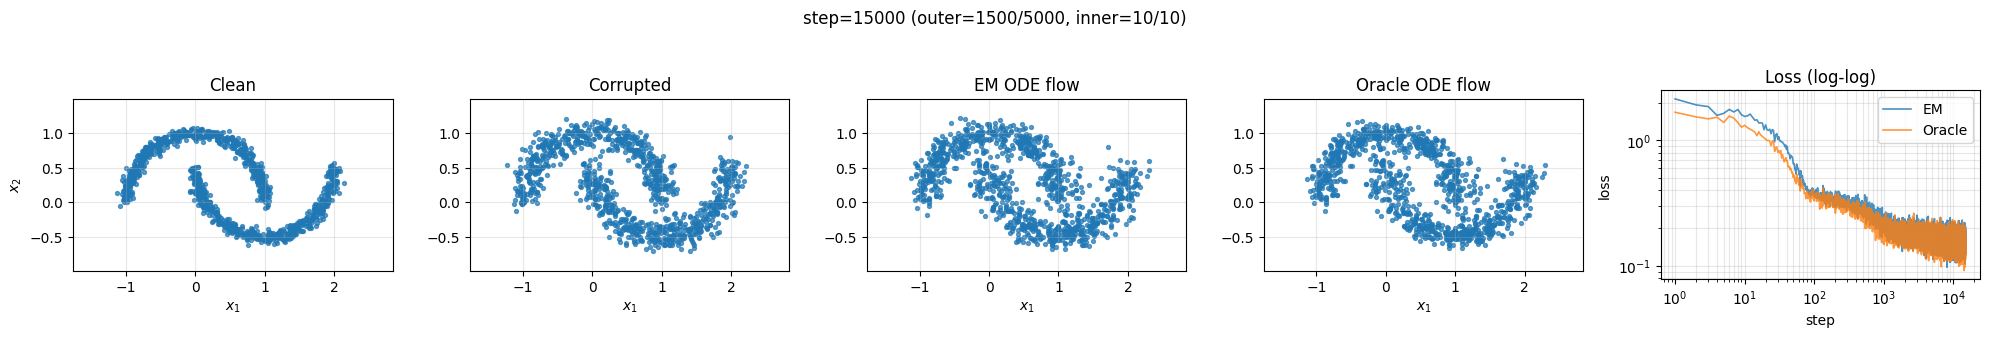

step=15100 (outer=1510/5000) loss_em=0.169214 loss_or=0.176024 lr=7.93e-05
step=15200 (outer=1520/5000) loss_em=0.188465 loss_or=0.177579 lr=7.91e-05
step=15300 (outer=1530/5000) loss_em=0.154014 loss_or=0.144599 lr=7.88e-05
step=15400 (outer=1540/5000) loss_em=0.173387 loss_or=0.171382 lr=7.86e-05
step=15500 (outer=1550/5000) loss_em=0.171383 loss_or=0.167208 lr=7.83e-05
step=15600 (outer=1560/5000) loss_em=0.152870 loss_or=0.155753 lr=7.81e-05
step=15700 (outer=1570/5000) loss_em=0.167229 loss_or=0.144884 lr=7.78e-05
step=15800 (outer=1580/5000) loss_em=0.121690 loss_or=0.124967 lr=7.75e-05
step=15900 (outer=1590/5000) loss_em=0.144429 loss_or=0.117233 lr=7.73e-05
step=16000 (outer=1600/5000) loss_em=0.152763 loss_or=0.160332 lr=7.70e-05
step=16100 (outer=1610/5000) loss_em=0.137277 loss_or=0.127182 lr=7.68e-05
step=16200 (outer=1620/5000) loss_em=0.113885 loss_or=0.125746 lr=7.65e-05
step=16300 (outer=1630/5000) loss_em=0.134161 loss_or=0.142919 lr=7.62e-05
step=16400 (outer=1640/50

In [ ]:
phi_k = copy.deepcopy(model_em).eval()

for k in range(t_outer):
    for i in range(t_inner):
        # Shared randomness across the two branches.
        z = torch.randn(batch_size, 2, device=device)
        t = torch.rand(batch_size, 1, device=device)                          # t in [0, 1), no clamp
        z_prime = torch.randn(batch_size, 2, device=device) if x0_independent else z

        # ---- Oracle branch (supervised) ----
        model_oracle.train()
        opt_oracle.zero_grad()
        x_clean = sample_clean(batch_size, data_kind, device)
        y_oracle = forward_corruption(x_clean, noise_std)
        I_t_or = (1 - t) * z_prime + t * x_clean
        b_target_or = x_clean - z_prime
        b_hat_or = model_oracle(I_t_or, y_oracle, t)
        loss_or = ((b_hat_or - b_target_or) ** 2).mean()
        loss_or.backward()
        torch.nn.utils.clip_grad_norm_(model_oracle.parameters(), max_grad_norm)
        opt_oracle.step()
        sched_oracle.step()
        loss_history_oracle.append(loss_or.item())

        # ---- EM branch (unsupervised) ----
        model_em.train()
        opt_em.zero_grad()
        y_real = sample_corrupted(batch_size, data_kind, noise_std, device)
        with torch.no_grad():
            x_em = flow(phi_k, z, y_real, n_steps=n_steps)
            y_fake = forward_corruption(x_em, noise_std)
        n_fake = int(batch_size * y_fake_ratio)
        n_fake = max(0, min(n_fake, batch_size))
        if n_fake == 0:
            y_cond = y_real
        elif n_fake == batch_size:
            y_cond = y_fake
        else:
            y_cond = torch.cat((y_fake[:n_fake], y_real[n_fake:]), dim=0)
        I_t_em = (1 - t) * z_prime + t * x_em
        b_target_em = x_em - z_prime
        b_hat_em = model_em(I_t_em, y_cond, t)
        loss_em_val = ((b_hat_em - b_target_em) ** 2).mean()
        loss_em_val.backward()
        torch.nn.utils.clip_grad_norm_(model_em.parameters(), max_grad_norm)
        opt_em.step()
        sched_em.step()
        loss_history_em.append(loss_em_val.item())

        global_step += 1

        if print_every > 0 and global_step % print_every == 0:
            current_lr = opt_em.param_groups[0]["lr"]
            print(
                f"step={global_step} (outer={k + 1}/{t_outer}) "
                f"loss_em={loss_em_val.item():.6f} loss_or={loss_or.item():.6f} "
                f"lr={current_lr:.2e}"
            )

        if sample_every > 0 and global_step % sample_every == 0:
            visualize_compare(
                model_em,
                model_oracle,
                data_kind,
                noise_std,
                title_prefix=(
                    f"step={global_step} "
                    f"(outer={k + 1}/{t_outer}, inner={i + 1}/{t_inner})"
                ),
                n_vis=n_vis,
                loss_em=loss_history_em,
                loss_oracle=loss_history_oracle,
            )

    phi_k = copy.deepcopy(model_em).eval()